Hands-On Lab: Building a Classifier

● Step 1: Train a LogisticRegression model on a provided classification dataset (e.g. churn).

● Step 2: Generate predictions and produce the confusion matrix.

● Step 3: Compute (precision, recall, and F1) with classification_report, and interpret each.

● Step 4: Decide whether precision or recall matters more for this specific problem and justify it.

● Step 5: Compute the AUC-ROC and document what it says about the model.

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.datasets import load_breast_cancer # It is a binary classification dataset with Two original classes: malignant and benign

from sklearn.model_selection import train_test_split

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler # we need to scale the features to have zero mean and unit variance, which is important for logistic regression. 
                                            # Without scaling, features with large numbers, such as area, can have a much larger effect on the model than features with small numbers, such as smoothness.
                                                                                                  
from sklearn.metrics import RocCurveDisplay # for visualizing the ROC curve

Load the data and split it:

In [26]:
model_0 = LogisticRegression(max_iter=1000) # load the model (doesnt scale data)

brCa = load_breast_cancer() # load the dataset

X = brCa.data #assign the features to X

y = (brCa.target == 0).astype(int) # convert the target variable to binary (orginally 0 for malignant, 1 for benign --->into 0 for benign, 1 for malignant)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # split the dataset into training and testing sets



Fit the model and make a prediction:

In [36]:

model = make_pipeline(StandardScaler(), model_0) # create a pipeline that first scales the features and then fits the logistic regression model (scales the data )

model.fit(X_train, y_train) # fit the model to the training data

prediction = model.predict(X_test) # make predictions on the test data

probabilities = model.predict_proba(X_test) # get the predicted probabilities for each class (class probabilities)  # used in calculating maliginant_probabilities (auc-roc)

Calculate accuracy, confusion matrix and the classification_report:

In [ ]:
accuracy = accuracy_score(y_test, prediction) # calculate the accuracy of the model
print("Accuracy:", accuracy) # print the accuracy of the model
  
    
cm = confusion_matrix(y_test, prediction)
print("\n confusion_matrix \n", cm) # print the confusion matrix 
  
cr = classification_report(y_test, prediction, target_names=['benign', 'malignant']) # generate a classification report (precision, recall, f1-score, support) for each class (benign and malignant)
print ("\nclassification_report", cr ) # print the classification report


Accuracy: 0.9736842105263158

 confusion_matrix 
 [[70  1]
 [ 2 41]]

classification_report               precision    recall  f1-score   support

      benign       0.97      0.99      0.98        71
   malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix:   
 --------------                 bengin ---     malignant      
 actual bengin------70----1  
 actual malignant----2----41 



Precision answers: "Of all patients predicted as malignant, how many were actually malignant?"
    "(Of everything I predicted positive, how much was right?)"

We aquired a malignant precision of 0.98 . (98% of the malignant predictions were correct)

Recall answers: "Of all patients who actually had malignant cancer, how many did the model detect?"
    "(Of all actual positives, how many did I catch?)"

we aquired a maliginant Recall of 0.95 . (model detected approximately 95% of the malignant cases)

F1-score: combines both.

A malignant F1-score of 0.96 indicates that the model has a strong balance between detecting malignant cases and avoiding incorrect malignant predictions.

Precision or Recall ? 

For Breast cancer detection, while both are desired and neccesary, recall is more important.   
having a False negative classifying a maliginant as a bengin would delay treatment and diagnosis.    
      "(never miss a real case)"

Calculate ROC- AUC:

In [ ]:
maliginant_probabilities = probabilities[:, 1] # get the predicted probabilities for the positive class (malignant) -we need this- 
benign_probabilities = probabilities[:, 0] # get the predicted probabilities for the negative class (benign)

auc_score = roc_auc_score(y_test, maliginant_probabilities) # calculate the ROC AUC score

print ("ROC AUC Score:", auc_score) # print the ROC AUC score


print ("\nROC Curve:", roc_curve(y_test, probabilities[:, 1])) # print the ROC curve

ROC AUC Score: 0.99737962659679

ROC Curve: (array([0.        , 0.        , 0.        , 0.01408451, 0.01408451,
       0.09859155, 0.09859155, 1.        ]), array([0.        , 0.02325581, 0.95348837, 0.95348837, 0.97674419,
       0.97674419, 1.        , 1.        ]), array([           inf, 1.00000000e+00, 7.76680319e-01, 5.42699821e-01,
       4.84826685e-01, 1.13099081e-01, 8.41633901e-02, 8.18375684e-07]))


ROC-AUC measures how well the model separates the two classes across different classification thresholds.   
It is to be calculated using predicted probabilities.   

An AUC closer to 1 means that the model is effictive at assigning higher malignant probabilities to malignant samples rather than the other.

The model achieved an AUC-ROC score of approximately 0.9973;  indicating excellent discrimination between malignant and benign tumors.

Simple Visualization of ROC:

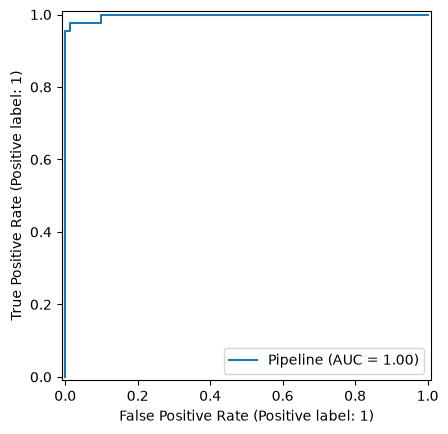

In [38]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
